# 07. AIMD (DFT) reference diffusivities

The AIMD data sets that the CHGNet and MACE models were trained on are also the DFT reference for the
MD comparisons in notebooks 03–05. They are analyzed here with exactly the same code and fit settings
as the foundation-potential MD.

| material | AIMD | temperatures |
|---|---|---|
| LYC, Li<sub>15</sub>Y<sub>7</sub>Cl<sub>36</sub> (58 atoms) | VASP PBE, NVT (Nosé), 2 fs, runs of 1,000 steps | 500, 600, 700, 800, 900 K |
| 20258, 45802, 75421 (Na conductors) | VASP PBE, NVT (Nosé–Hoover, MDALGO = 2), 2 fs, runs of 200 steps | 800, 900, 1000, 1150, 1300 K |

Consecutive VASP runs (`RUN_1`, `RUN_2`, …; each starts from the previous `CONTCAR`) are stitched into one
trajectory after checking that each run starts where the previous one ended. `RUN_0` (heating) and the
first 10 ps are discarded; every 10th step (20 fs) is used for the MSD.

### Diffusion analysis (same for every MD notebook in this repository)

Implemented in `iondiff/` (adapted from the MoGroup diffusion module; method of X. He, Y. Zhu, A. Epstein,
Y. Mo, *npj Comput. Mater.* **4**, 18 (2018)):

* **Trajectory**: jobs that continue a previous job (first frame identical to the previous last frame)
  are concatenated after dropping the duplicated frame; equilibration frames are removed only at the
  start of each chain. NPT displacements use each frame's own cell.
* **MSD**: time-averaged (FFT) mean squared displacement of the mobile ion, with the framework
  centre-of-mass drift removed; fitted linearly between MSD = 0.5 a² and 0.8 of the trajectory length
  (a = 3.38 Å, average hop distance), requiring at least 0.5 a² of MSD change. D = slope / 6.
* **Statistical error of D**: RSD = 3.43 / √N<sub>jump</sub> + 0.04 with N<sub>jump</sub> = n<sub>ions</sub>
  · max(MSD) / a² (He et al. 2018); σ<sub>D</sub> = RSD · D.
* **Framework melting**: a temperature is marked *melted* when the framework (all non-mobile atoms)
  diffuses, i.e. their time-averaged MSD at the end of the fit window exceeds a². Isolated framework
  hops (a few atoms moving > 4 Å) do not count; they are recorded separately.
* **Arrhenius fit (primary)**: least squares on log<sub>10</sub>D vs 1000/T, weighted by
  σ<sub>log10 D</sub>, using temperatures where the MSD fit succeeded and the framework did not melt.
  Fits that keep melted temperatures, and unweighted fits, are shown for comparison.
* **Conductivity**: Nernst–Einstein, σ = n z² e² D / (V k<sub>B</sub> T); σ(300 K) is extrapolated
  from the fit (the range comes from the fit uncertainty).

In [1]:
import pandas as pd
from plot_style import plt, save, PALETTE
import md_results as mr

lyc = mr.load("aimd_lyc"); na = mr.load("aimd_na_conductors")
series = {"LYC": lyc["series"][0]} | {s["label"].split()[-1]: s for s in na["series"]}
rows = []
for m, s in series.items():
    for r in s["temperatures"]:
        rows.append({"material": m, "T (K)": r["temperature_K"], "VASP runs": len(r["segments"]),
                     "independent chains": r.get("n_independent_chains"), "analyzed (ps)": round(r["analyzed_time_ps"], 1),
                     "D (cm2/s)": r.get("D_cm2_s"), "RSD": round(r["D_rsd"], 2) if r.get("D_rsd") else None,
                     "framework MSD (A2)": round(r["framework_msd_at_fit_end_A2"], 2)})
pd.DataFrame(rows).set_index(["material", "T (K)"])

VASP runs  independent chains  analyzed (ps)  D (cm2/s)  \
material T (K)                                                             
LYC      500.0         103                   1          204.0   0.000003   
         600.0          99                   1          196.0   0.000008   
         700.0          95                   1          188.0   0.000013   
         800.0          62                   1          122.0   0.000029   
         900.0          35                   1           68.0   0.000042   
20258    800.0        1075                   1          429.6   0.000003   
         900.0        1000                   1          399.6   0.000005   
         1000.0        909                   1          363.2   0.000012   
         1150.0        606                   1          242.0   0.000021   
         1300.0        365                   1          145.6   0.000034   
45802    800.0         940                   1          375.6   0.000034   
         900.0         794                   1          317.2   0.000045   
         1000.0        478                   1          190.8   0.000066   
         1150.0        439                   1          175.2   0.000084   
         1300.0        254                   1          101.2   0.000095   
75421    800.0         479                   1          191.2   0.000024   
         900.0         418                   1          166.8   0.000037   
         1000.0        211                   1           84.0   0.000055   
         1150.0        267                   1          106.4   0.000064   
         1300.0        315                   1          125.6   0.000050   

                  RSD  framework MSD (A2)  
material T (K)                             
LYC      500.0   0.49                0.23  
         600.0   0.33                0.27  
         700.0   0.29                0.32  
         800.0   0.24                0.39  
         900.0   0.27                0.49  
20258    800.0   0.46                0.43  
         900.0   0.31                0.47  
         1000.0  0.26                0.80  
         1150.0  0.26                0.83  
         1300.0  0.25                1.46  
45802    800.0   0.21                0.15  
         900.0   0.21                0.16  
         1000.0  0.21                0.18  
         1150.0  0.22                0.21  
         1300.0  0.21                0.23  
75421    800.0   0.22                0.16  
         900.0   0.21                0.19  
         1000.0  0.22                0.21  
         1150.0  0.22                0.22  
         1300.0  0.22                0.25

In [2]:
mr.summary_table(lyc).append(mr.summary_table(na)) if hasattr(pd.DataFrame, "append") else pd.concat([mr.summary_table(lyc), mr.summary_table(na)])

,temperatures,total analyzed time (ns),MSD fit ok,framework melted,T used in fit (K),Ea (eV),Ea std (eV),R2,sigma(300 K) extrapolated (mS/cm),sigma(300 K) range (mS/cm)
model,,,,,,,,,,
AIMD (PBE),5,0.8,5,0,500-900 (5),0.265,0.045,0.989,3.02,0.45-20.07
AIMD (PBE) 20258,5,1.6,5,0,800-1300 (5),0.439,0.074,0.992,0.00,0.00-0.07
AIMD (PBE) 45802,5,1.2,5,0,800-1300 (5),0.191,0.048,0.980,9.22,1.35-63.09
AIMD (PBE) 75421,5,0.7,5,0,800-1300 (5),0.148,0.049,0.714,28.96,3.92-214.27


'figures/md/aimd_reference_arrhenius.png'

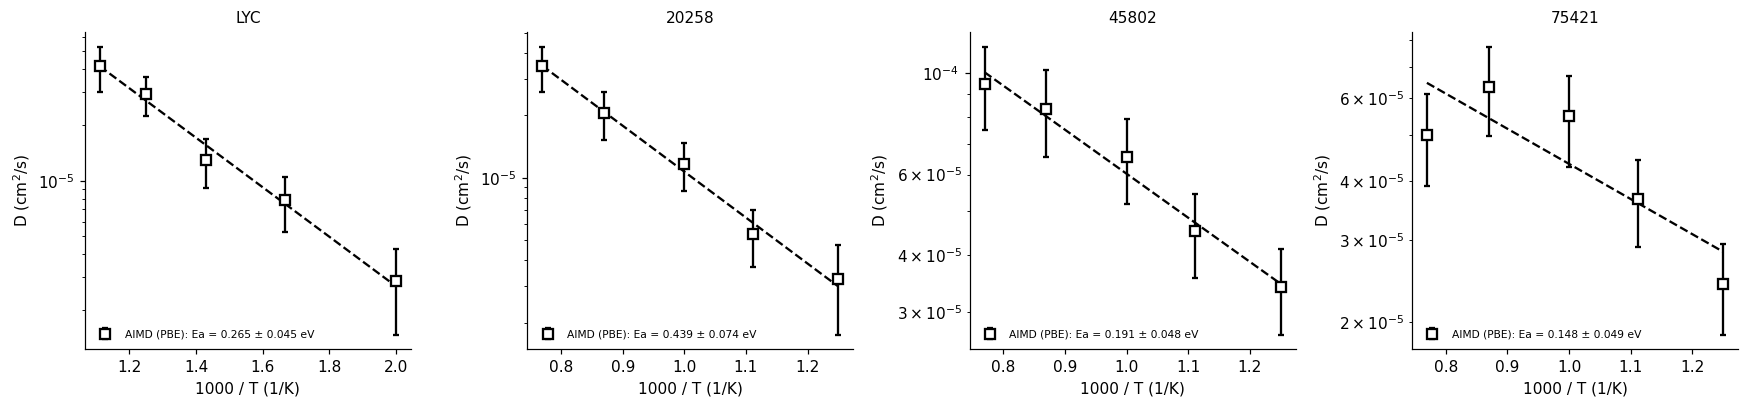

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, (m, s) in zip(axes, series.items()):
    mr.aimd_overlay(ax, s); ax.set_title(m); ax.legend(frameon=False, fontsize=7, loc="lower left")
    ax.set_xlabel("1000 / T (1/K)"); ax.set_ylabel("D (cm$^2$/s)")
fig.tight_layout(); save(fig, "md/aimd_reference_arrhenius")

## Cross-check against the earlier analysis of the same AIMD

`results/aimd_previous_analysis/` holds the D(T) tables produced earlier with the original MoGroup
module (same RSD formula; the exact run ranges used then are not recorded). Ratio = this analysis /
earlier analysis.

In [4]:
files = {"LYC": "lyc_D_T.csv", "20258": "20258_D_T.csv", "45802": "45802_D_T.csv", "75421": "75421_D_T.csv"}
rows = []
for m, f in files.items():
    old = pd.read_csv(f"../results/aimd_previous_analysis/{f}")
    new = {r["temperature_K"]: r for r in series[m]["temperatures"]}
    for _, o in old.sort_values("T").iterrows():
        n = new.get(float(o["T"]))
        rows.append({"material": m, "T (K)": int(o["T"]), "D earlier": o["D"], "D this analysis": n["D_cm2_s"] if n else None,
                     "ratio": round(n["D_cm2_s"] / o["D"], 2) if n else None,
                     "RSD this analysis": round(n["D_rsd"], 2) if n else None})
pd.DataFrame(rows).set_index(["material", "T (K)"])

D earlier  D this analysis  ratio  RSD this analysis
material T (K)                                                      
LYC      500     0.000002         0.000003   1.90               0.49
         600     0.000006         0.000008   1.34               0.33
         700     0.000017         0.000013   0.75               0.29
         800     0.000025         0.000029   1.17               0.24
         900     0.000042         0.000042   1.00               0.27
20258    800     0.000005         0.000003   0.68               0.46
         900     0.000005         0.000005   0.99               0.31
         1000    0.000014         0.000012   0.82               0.26
         1150    0.000021         0.000021   1.00               0.26
         1300    0.000034         0.000034   1.00               0.25
45802    800     0.000045         0.000034   0.76               0.21
         900     0.000045         0.000045   1.00               0.21
         1000    0.000076         0.000066   0.86               0.21
         1150    0.000084         0.000084   0.99               0.22
         1300    0.000091         0.000095   1.04               0.21
75421    800     0.000024         0.000024   1.01               0.22
         900     0.000037         0.000037   1.00               0.21
         1000    0.000053         0.000055   1.04               0.22
         1150    0.000064         0.000064   1.00               0.22
         1300    0.000050         0.000050   0.99               0.22

## Findings

* **AIMD activation energies (same analysis as the MD):** LYC 0.265 ± 0.045 eV (500–900 K),
  20258 0.439 ± 0.074 eV, 45802 0.191 ± 0.048 eV and 75421 0.148 ± 0.049 eV (800–1300 K).
* **Agreement with the earlier analysis of the same AIMD:** 12 of the 20 diffusivities agree within 5%;
  the others differ by 0.68–1.90×, within about two of their statistical uncertainties (RSD 0.21–0.49).
  The earlier run ranges are not recorded, so some of the difference may come from different amounts
  of data.
* **75421:** D at 1300 K is lower than at 1150 K (also in the earlier analysis), and its Arrhenius fit
  has R² = 0.71; its E<sub>a</sub> is the least certain of the four.
* **The framework stays solid in every AIMD run** (framework MSD ≤ 1.5 Å² against the 11.4 Å² melt
  criterion).
* **The AIMD are short compared with the MD** (68–430 ps per temperature, 5 temperatures), so their
  E<sub>a</sub> uncertainties (±0.045–0.074 eV) are 3–5× those of the FP MD.